This will be a dummy model of spatial glue 

# Imports

In [22]:
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import sklearn
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from SpatialGlue import (
    SpatialGlueMini,
    train_model,
    reconstruction_loss,
    correspondence_loss,
    total_loss
)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

import torch_geometric
print("pyg:", torch_geometric.__version__)

torch: 2.10.0+cu126
cuda available: True
pyg: 2.7.0


# Helpers

In [3]:

def knn_edge_index(X, k):
    """
    Build a KNN graph and return edge_index for PyTorch Geometric.

    Parameters
    ----------
    X : numpy array (N, d)
        Feature matrix or coordinates
    k : int
        Number of nearest neighbors

    Returns
    -------
    edge_index : torch.LongTensor (2, E)
    """

    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X)
    distances, indices = nbrs.kneighbors(X)

    edges = []

    for i in range(X.shape[0]):
        for j in indices[i, 1:]:  # skip self neighbor
            edges.append([i, j])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    return edge_index

# Data Preprocess




In [4]:
#import data
adata_rna = sc.read_h5ad("../Data/GSE263617_RAW/GSM8195494_A1_LN.h5ad")
adata_prot = sc.read_h5ad("../Data/GSE263617_RAW/GSM8195498_A1_LN_Protein.h5ad")

print(adata_rna)
print(adata_prot)

print(adata_rna.obs_names[:5])
print(adata_prot.obs_names[:5])

print(adata_rna.obsm_keys())
print(adata_prot.obsm_keys())



AnnData object with n_obs × n_vars = 3484 × 17954
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    obsm: 'feat', 'spatial'
AnnData object with n_obs × n_vars = 3484 × 31
    var: 'gene_ids', 'feature_types', 'genome', 'mean', 'std'
    obsm: 'feat', 'spatial'
Index(['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1',
       'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1'],
      dtype='object')
Index(['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1',
       'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1'],
      dtype='object')
['feat', 'spatial']
['feat', 'spatial']


C:\Users\imoha\AppData\Local\Temp\ipykernel_30492\3663242706.py:11: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  print(adata_rna.obsm_keys())
C:\Users\imoha\AppData\Local\Temp\ipykernel_30492\3663242706.py:12: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  print(adata_prot.obsm_keys())


In [5]:
#ensure rows correspond to specific spots
common = adata_rna.obs_names.intersection(adata_prot.obs_names)
print(len(common), adata_rna.n_obs, adata_prot.n_obs)

adata_rna  = adata_rna[common].copy()
adata_prot = adata_prot[common].copy()

assert all(adata_rna.obs_names == adata_prot.obs_names)

3484 3484 3484


The provided dataset (GSE263617) has already been preprocessed by the dataset authors.  
Instead of raw expression matrices, the `.h5ad` files contain **low-dimensional feature embeddings** stored in `obsm["feat"]`. These embeddings represent processed molecular features for each spatial spot.

The preprocessing steps performed before release include:

- **Normalization and log transformation** of gene expression counts.
- **Feature selection** (e.g., highly variable genes) to remove uninformative genes.
- **Dimensionality reduction** (e.g., PCA or a similar embedding method) to project the data into a compact feature space.
- The resulting **30-dimensional feature vectors** per spot are stored in `obsm["feat"]`.

Additional metadata provided in the dataset:

- **Spatial coordinates** for each spot are stored in `obsm["spatial"]`.
- Each modality (RNA and protein) contains the **same set of spatial spots**, enabling direct multimodal integration.

For this implementation, the model uses:
- `obsm["feat"]` as the **input feature matrix** for each modality.
- `obsm["spatial"]` as the **coordinate matrix** for constructing the spatial graph.

No additional normalization, HVG selection, or dimensionality reduction is required before building the model.

In [6]:
import numpy as np

feat = adata_rna.obsm["feat"]
print("feat type:", type(feat))
print("feat shape:", feat.shape)
print("feat sample:\n", feat[:5, :5])
print("feat nan count:", np.isnan(feat).sum())
print("feat inf count:", np.isinf(feat).sum())
print("feat min:", np.min(feat))
print("feat max:", np.max(feat))

feat type: <class 'numpy.ndarray'>
feat shape: (3484, 30)
feat sample:
 [[-0.5286072  -1.968712   -2.0304449  -0.23735158  2.2405927 ]
 [-0.23265669 -4.3911138  -1.0673895  -0.7247689   0.27467248]
 [-0.7726885  -1.3906536  -0.5353154   1.2743682   0.41763404]
 [ 9.991095    1.8768612  -3.973482    1.1121707   0.99051243]
 [22.483023    4.5754642   6.119782   -3.3744297   0.7280182 ]]
feat nan count: 0
feat inf count: 0
feat min: -22.674479
feat max: 53.386665


In [7]:
import numpy as np

print(adata_prot)
print("obsm keys:", list(adata_prot.obsm.keys()))

feat_p = adata_prot.obsm["feat"]
print("protein feat type:", type(feat_p))
print("protein feat shape:", feat_p.shape)
print("protein feat sample:\n", feat_p[:5, :5])
print("protein feat nan count:", np.isnan(feat_p).sum())
print("protein feat inf count:", np.isinf(feat_p).sum())
print("protein feat min:", np.min(feat_p))
print("protein feat max:", np.max(feat_p))

AnnData object with n_obs × n_vars = 3484 × 31
    var: 'gene_ids', 'feature_types', 'genome', 'mean', 'std'
    obsm: 'feat', 'spatial'
obsm keys: ['feat', 'spatial']
protein feat type: <class 'numpy.ndarray'>
protein feat shape: (3484, 30)
protein feat sample:
 [[-1.45135903e+00 -6.89919353e-01 -3.00473869e-01  6.57826900e-01
   9.86466289e-01]
 [-1.90094066e+00 -1.21078789e+00 -2.20574182e-03  3.76000226e-01
  -1.20343775e-01]
 [-1.04118931e+00 -3.50732684e-01 -5.58240950e-01 -3.47659409e-01
   5.31457543e-01]
 [-1.66520941e+00  1.77653825e+00  9.65626091e-02  1.88987327e+00
  -9.16671380e-02]
 [-1.34772801e+00  2.89444494e+00 -2.53138363e-01 -1.33347571e+00
  -1.27070379e+00]]
protein feat nan count: 0
protein feat inf count: 0
protein feat min: -16.947506
protein feat max: 33.487038


In [8]:
#Final working data
X_rna = adata_rna.obsm["feat"].astype("float32")
X_prot = adata_prot.obsm["feat"].astype("float32")
coords = adata_rna.obsm["spatial"].astype("float32")


# Step 1: Building Spatial, RNA feature, and Protien Feature Graphs 

In [9]:
spatial_edge_index = knn_edge_index(coords, k=3)

In [14]:
rna_feature_edge_index = knn_edge_index(X_rna, k=20)
prot_feature_edge_index = knn_edge_index(X_prot, k=20)

In [15]:
#convert into tensors for analysis
X_rna_t = torch.tensor(X_rna, dtype=torch.float32)
X_prot_t = torch.tensor(X_prot, dtype=torch.float32)

# Step 2: Model Init and Train

In [16]:
model = SpatialGlueMini(
    in_dim = 30,
    hidden_dim = 64,
    latent_dim = 32,
    num_modalities = 2,
    dropout = 0.1
)

In [17]:
model = train_model(
    model,
    xs=[X_rna_t, X_prot_t],
    spatial_edge_index=spatial_edge_index,
    feature_edge_indices=[rna_feature_edge_index, prot_feature_edge_index],
    epochs=500,
    lr=1e-4
)

Epoch 0000 | total=12.9828 | recon=8.0999 | corr=4.8829
Epoch 0050 | total=9.7605 | recon=7.8744 | corr=1.8861
Epoch 0100 | total=9.1672 | recon=7.7528 | corr=1.4144
Epoch 0150 | total=8.7493 | recon=7.6065 | corr=1.1427
Epoch 0200 | total=8.3711 | recon=7.4350 | corr=0.9361
Epoch 0250 | total=8.0139 | recon=7.1789 | corr=0.8350
Epoch 0300 | total=7.5855 | recon=6.8226 | corr=0.7628
Epoch 0350 | total=7.0998 | recon=6.3840 | corr=0.7157
Epoch 0400 | total=6.5906 | recon=5.8871 | corr=0.7035
Epoch 0450 | total=6.1016 | recon=5.4152 | corr=0.6863


In [18]:
model.eval()

with torch.no_grad():
    outputs = model(
        [X_rna_t, X_prot_t],
        spatial_edge_index,
        [rna_feature_edge_index, prot_feature_edge_index]
    )

Z = outputs["z"].cpu().numpy()

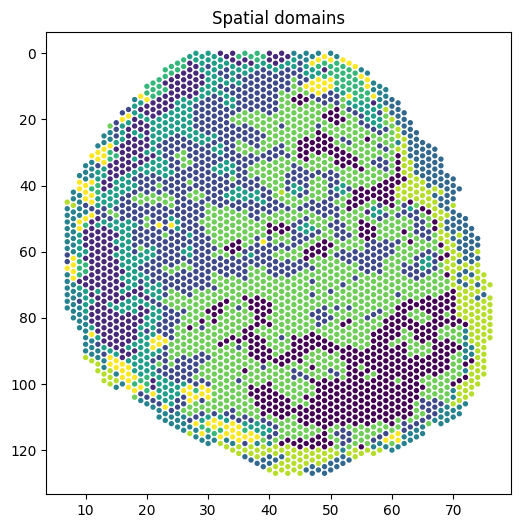

In [23]:

labels = KMeans(n_clusters=10).fit_predict(Z)


plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], c=labels, s=8)
plt.gca().invert_yaxis()
plt.title("Spatial domains")
plt.show()

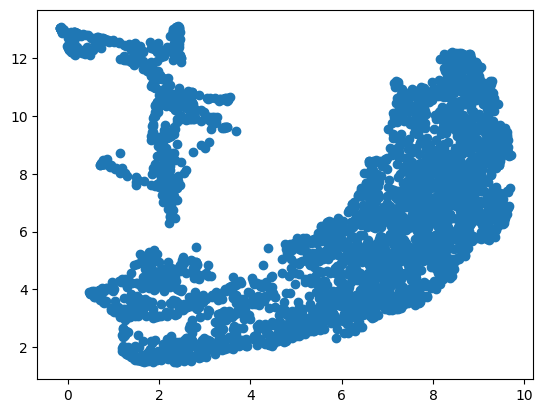

In [25]:
import umap
embedding = Z

reducer = umap.UMAP()
z = reducer.fit_transform(embedding)

plt.scatter(z[:,0], z[:,1])

In [26]:
nbrs = NearestNeighbors(n_neighbors=6).fit(coords)
dist, idx = nbrs.kneighbors(coords)